# Chapter 16 - Decision Trees

Decision Trees are models that make predictions by asking a sequence of simple
questions. Each question splits the data into smaller groups, and the final
group gives the prediction.

In this chapter, we will use a small student placement dataset and train a
Decision Tree to predict whether a student is placed based on CGPA and IQ.


## Step 1 - Import Libraries and Load the Dataset

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [32]:
student_data_url = "https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch16/students.csv"

df = pd.read_csv(student_data_url)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (100, 3)
           IQ      CGPA  Placed
0  116.521863  7.839804       1
1  111.114991  7.230805       1
2  109.839861  7.253657       1
3   99.772056  5.960763       0
4  111.693979  9.576941       1


The dataset has three columns:

- `CGPA`: student's academic score
- `IQ`: student's IQ score
- `Placed`: target column, where 1 means placed and 0 means not placed


In [33]:
print("Column information:")
print(df.info())

print("\nClass distribution:")
print(df["Placed"].value_counts().sort_index())


Column information:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IQ      100 non-null    float64
 1   CGPA    100 non-null    float64
 2   Placed  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None

Class distribution:
Placed
0    50
1    50
Name: count, dtype: int64


## Step 2 - Understand the Decision Tree Idea

A Decision Tree behaves like a flowchart. It asks questions such as:

- Is CGPA less than or equal to a certain value?
- Is IQ less than or equal to a certain value?

Each answer moves the row to the left or right branch. After a few such
questions, the row reaches a leaf node, and the leaf node gives the final
prediction.

For classification, CART usually uses Gini impurity to decide which split is
useful. 

- A pure node has only one class and has Gini impurity 0. 
- A mixed node has higher impurity.


In [34]:
# A tiny Gini helper to connect the formula with actual numbers.
def gini_impurity(class_counts):
    total = sum(class_counts)
    probabilities = [count / total for count in class_counts]
    return 1 - sum(probability ** 2 for probability in probabilities)

root_counts = df["Placed"].value_counts().sort_index().tolist()
print("Class counts at the root node:", root_counts)
print("Root node Gini impurity:", round(gini_impurity(root_counts), 4))


Class counts at the root node: [50, 50]
Root node Gini impurity: 0.5


The root node contains the full dataset. Because both classes are present, the
impurity is above 0. 

The tree will now try splits on CGPA and IQ and choose the split that reduces impurity the most.


## Step 3 - Prepare Features and Target

We use the two input columns `CGPA` and `IQ`, to predict the
output column `Placed`.


In [35]:
# input features
X = df[["CGPA", "IQ"]]

# output
y = df["Placed"]

print("Feature preview:")
print(X.head())

print("\nTarget preview:")
print(y.head())


Feature preview:
       CGPA          IQ
0  7.839804  116.521863
1  7.230805  111.114991
2  7.253657  109.839861
3  5.960763   99.772056
4  9.576941  111.693979

Target preview:
0    1
1    1
2    1
3    0
4    1
Name: Placed, dtype: int64


## Step 4 - Train-Test Split

We split the data so that the tree learns from one part and is evaluated on
unseen rows. This checks whether the model learned a useful pattern instead of
only memorizing the training data.


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training feature shape: (70, 2)
Testing feature shape: (30, 2)

Training target shape: (70,)
Testing target shape: (30,)


## Step 5 - Train the Decision Tree

Decision Trees need very little preprocessing for numerical features. 

We do not need feature scaling or normalization here. 

The tree can directly work with the raw CGPA and IQ values.


In [37]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

print("Decision Tree training is complete.")
print("Tree depth:", tree.get_depth())
print("Number of leaf nodes:", tree.get_n_leaves())


Decision Tree training is complete.
Tree depth: 3
Number of leaf nodes: 4


A deeper tree can create more rules. This can be useful, but it can also make
the model memorize small details in the training data.


## Step 6 - Evaluate the Model

Accuracy tells us what fraction of test rows were classified correctly.


In [38]:
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", round(accuracy, 4))

comparison = X_test.copy()
comparison["Actual Placed"] = y_test.values
comparison["Predicted Placed"] = y_pred
comparison.head(10)


Accuracy = 0.9667


,CGPA,IQ,Actual Placed,Predicted Placed
76,7.480933,92.632196,0,0
87,7.398664,104.618039,0,0
71,10.000000,117.440493,1,1
44,7.843512,109.250244,0,0
86,8.224492,97.457809,0,0
4,9.576941,111.693979,1,1
8,8.698077,107.376213,1,0
72,7.654700,127.057516,1,1
94,6.470276,123.203175,1,1
40,7.315392,102.969246,0,0


The comparison table lets us inspect a few unseen rows. 

If the actual and predicted labels match often, the tree is generalizing reasonably well on the
test set.


## Step 7 - Visualize the Decision Boundary

Since this dataset has only two features, we can draw the CGPA-IQ plane and
show which regions the tree marks as "placed" or "not placed".

Decision Tree boundaries are block-like because each split checks one feature
at a time. 

A CGPA split creates a vertical cut, and an IQ split creates a
horizontal cut.


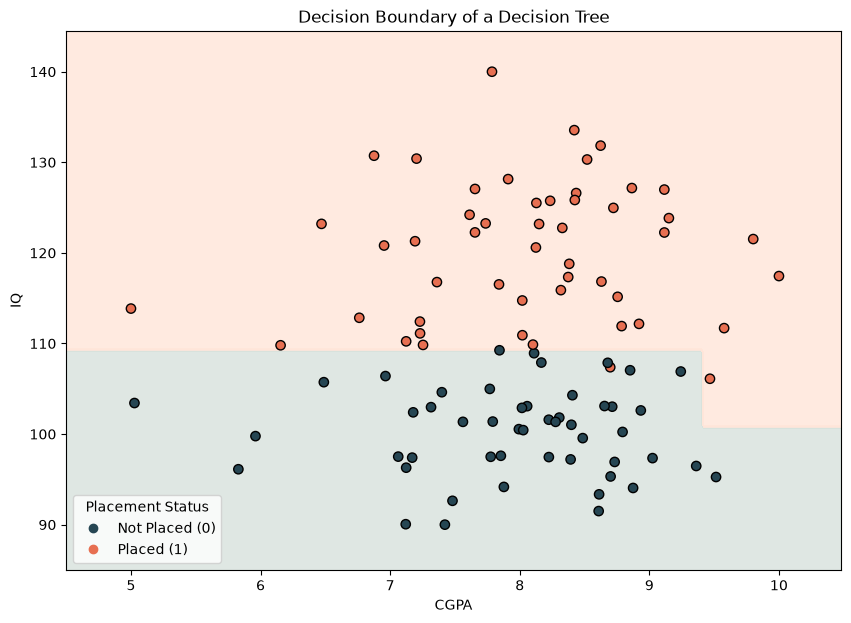

In [39]:
x_min = X["CGPA"].min() - 0.5
x_max = X["CGPA"].max() + 0.5
y_min = X["IQ"].min() - 5
y_max = X["IQ"].max() + 5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.5),
)

mesh_points = pd.DataFrame({
    "CGPA": xx.ravel(),
    "IQ": yy.ravel(),
})
Z = tree.predict(mesh_points).reshape(xx.shape)

bg_colors = ListedColormap(["#d8e2dc", "#ffe5d9"])
point_colors = ListedColormap(["#264653", "#e76f51"])

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=bg_colors)
scatter = plt.scatter(
    X["CGPA"],
    X["IQ"],
    c=y,
    cmap=point_colors,
    edgecolor="black",
    s=45,
)
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Decision Boundary of a Decision Tree")
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=["Not Placed (0)", "Placed (1)"],
    title="Placement Status",
    loc="lower left",
)
plt.show()


The rectangular regions show how the tree divides the feature space. 

Clean, broad regions usually represent useful patterns. 

Many tiny rectangles can be a warning sign that the tree is overfitting.


## Step 8 - Overfitting in Decision Trees

A Decision Tree can keep splitting until it creates very small regions. 

This can make training accuracy very high, but test accuracy may suffer because the
tree has memorized noise.

We compare training and testing accuracy to check this behavior.


In [40]:
train_accuracy = accuracy_score(y_train, tree.predict(X_train))
test_accuracy = accuracy_score(y_test, tree.predict(X_test))

print("Training accuracy:", round(train_accuracy, 4))
print("Testing accuracy:", round(test_accuracy, 4))
print("Tree depth:", tree.get_depth())
print("Leaf nodes:", tree.get_n_leaves())


Training accuracy: 1.0
Testing accuracy: 0.9667
Tree depth: 3
Leaf nodes: 4


If training accuracy is much higher than testing accuracy, the tree may be
overfitting. 

We handle this by using pruning rules.


## Step 9 - Pre-Pruning with `max_depth`

Pre-pruning means we restrict the tree while it is being trained. 

The simplest restriction is `max_depth`, which limits how many levels the tree can grow.


In [41]:
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train, y_train)

print("Shallow tree training accuracy:", round(accuracy_score(y_train, shallow_tree.predict(X_train)), 4))
print("Shallow tree testing accuracy:", round(accuracy_score(y_test, shallow_tree.predict(X_test)), 4))
print("\nShallow tree depth:", shallow_tree.get_depth())
print("Shallow tree leaf nodes:", shallow_tree.get_n_leaves())


Shallow tree training accuracy: 1.0
Shallow tree testing accuracy: 0.9667

Shallow tree depth: 3
Shallow tree leaf nodes: 4


A shallow tree is easier to read and less likely to memorize tiny regions. 

If it is too shallow, however, it can underfit and miss important patterns.


## Step 10 - Other Pre-Pruning Rules

We have four common pre-pruning controls:

- `max_depth`: limits the depth of the tree
- `min_samples_split`: requires enough samples before a node can split
- `min_samples_leaf`: requires enough samples in every final leaf
- `max_leaf_nodes`: limits the number of final decision regions

In practice, we can combine these rules to make the tree simpler and more
reliable.


In [42]:
pruned_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
)
pruned_tree.fit(X_train, y_train)

print("Pruned tree training accuracy:", round(accuracy_score(y_train, pruned_tree.predict(X_train)), 4))
print("Pruned tree testing accuracy:", round(accuracy_score(y_test, pruned_tree.predict(X_test)), 4))
print("\nPruned tree depth:", pruned_tree.get_depth())
print("Pruned tree leaf nodes:", pruned_tree.get_n_leaves())


Pruned tree training accuracy: 0.9857
Pruned tree testing accuracy: 0.9667

Pruned tree depth: 2
Pruned tree leaf nodes: 3


These settings tell the tree to prefer broader, more stable patterns instead
of creating a rule from very small groups of samples.


## Step 11 - Interpret the Tree

One reason Decision Trees are useful is that the learned rules can be drawn as
a flowchart. 
- Each internal node asks a yes/no question and 
- each leaf gives a final prediction.


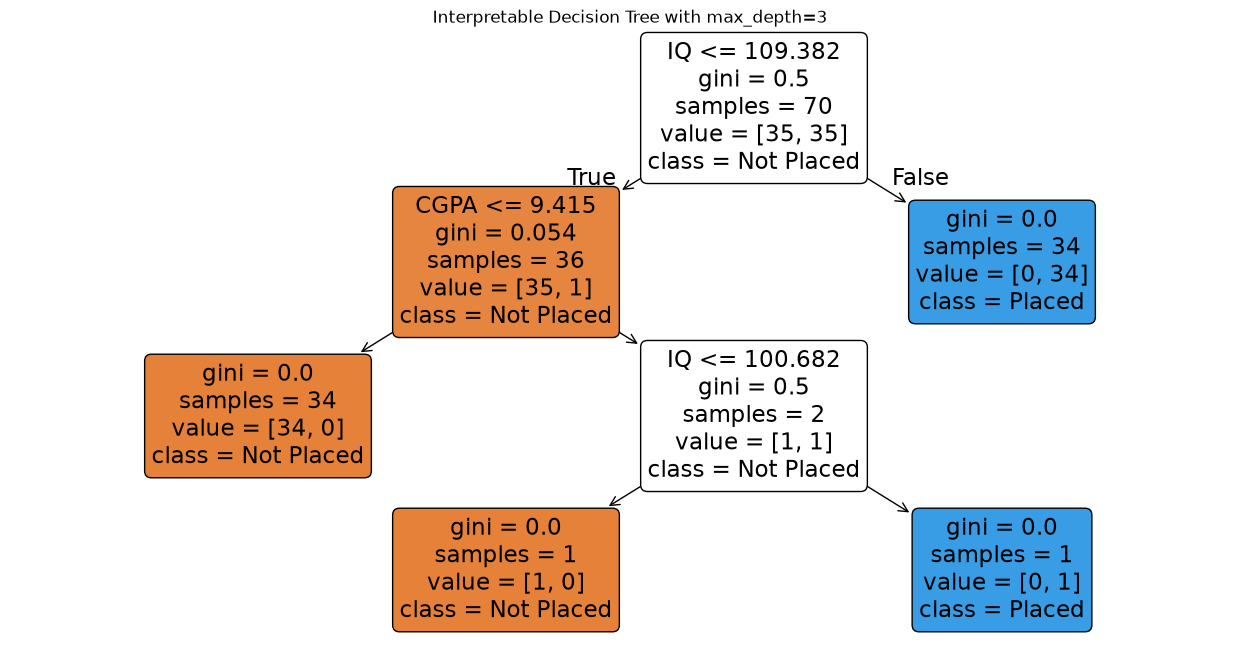

In [43]:
plt.figure(figsize=(16, 8))
plot_tree(
    shallow_tree,
    feature_names=["CGPA", "IQ"],
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    impurity=True,
)
plt.title("Interpretable Decision Tree with max_depth=3")
plt.show()


The tree diagram shows the model's reasoning. 

We can trace a row from the root node to a leaf and explain why it was predicted as placed or not placed.


## Chapter Recap

- A Decision Tree predicts by asking a sequence of simple feature-based
  questions.
- CART chooses splits by reducing impurity, commonly Gini impurity for
  classification.
- Decision Trees need little preprocessing for numerical features.
- The decision boundary is made of rectangular regions because splits are
  axis-aligned.
- Trees can overfit when they grow too deep.
- Pre-pruning controls such as `max_depth`, `min_samples_split`,
  `min_samples_leaf`, and `max_leaf_nodes` help keep the model simpler.
- A single Decision Tree is useful when clarity, speed, and interpretability
  matter. For stronger accuracy and stability, tree-based ensembles are often
  preferred.
